## 3.6.1 Yi et al. 2019

**Concepts:** [Exact optimization](../routers.md#exact-optimization)

In [1]:
import pickle

In [2]:
from importlib.resources import files

In [3]:
from optiwindnet.interarraylib import G_from_S
from optiwindnet.svg import svgplot
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.baselines.hgs import hgs_cvrp
from optiwindnet.importer import L_from_yaml
from optiwindnet.pathfinding import PathFinder
from optiwindnet.MILP import solver_factory, ModelOptions
from optiwindnet.interarraylib import as_normalized

### Reference solution

Yi, X., Scutariu, M., & Smith, K. (2019). Optimisation of offshore wind farm inter-array collection system. IET Renewable Power Generation, 13(11), 1990–1999. https://doi.org/10.1049/iet-rpg.2018.5805

The network was not parsed from the paper, using the published total cable lengths:

- radial: 162.3 km
- branched: 154.6 km

In [4]:
λ_radial = 162300
λ_branched = 154600

### Start here

In [5]:
solver = solver_factory('gurobi')

In [6]:
base_dir = files('optiwindnet.data')
inputfile = base_dir / 'Yi-2019.yaml'
L = L_from_yaml(inputfile)

In [7]:
P, A = make_planar_embedding(L)
A_norm = as_normalized(A)

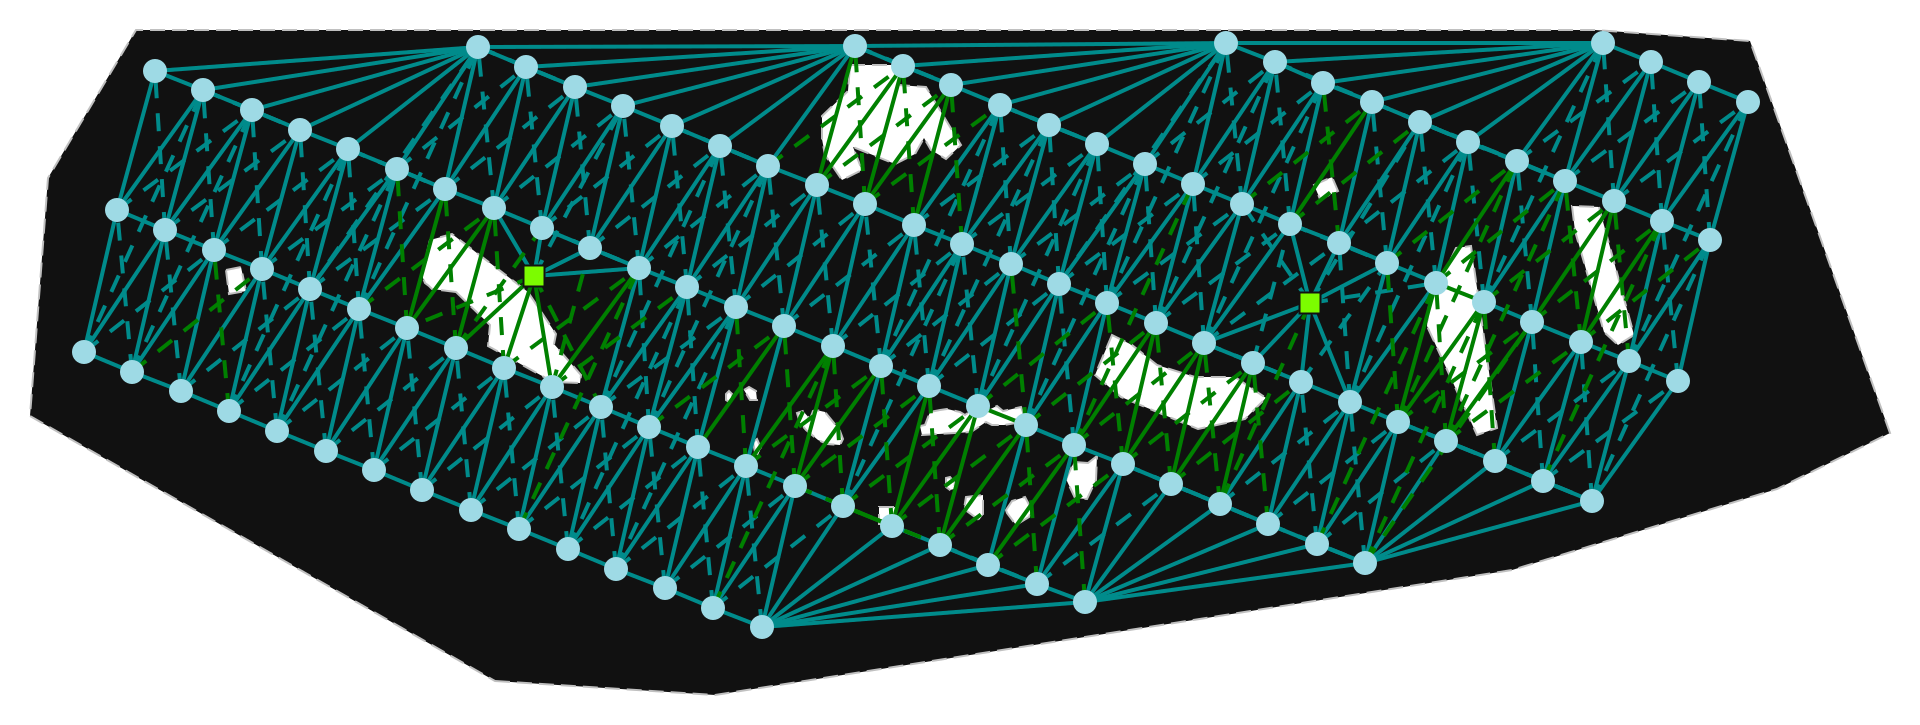

In [8]:
svgplot(A)

### Solve κ = 6 (branched)

In [9]:
Sʹ = hgs_cvrp(A_norm, capacity=6, time_limit=0.5, vehicles=20)
Sʹ.graph['solution_time']

(0.16, 0.18)

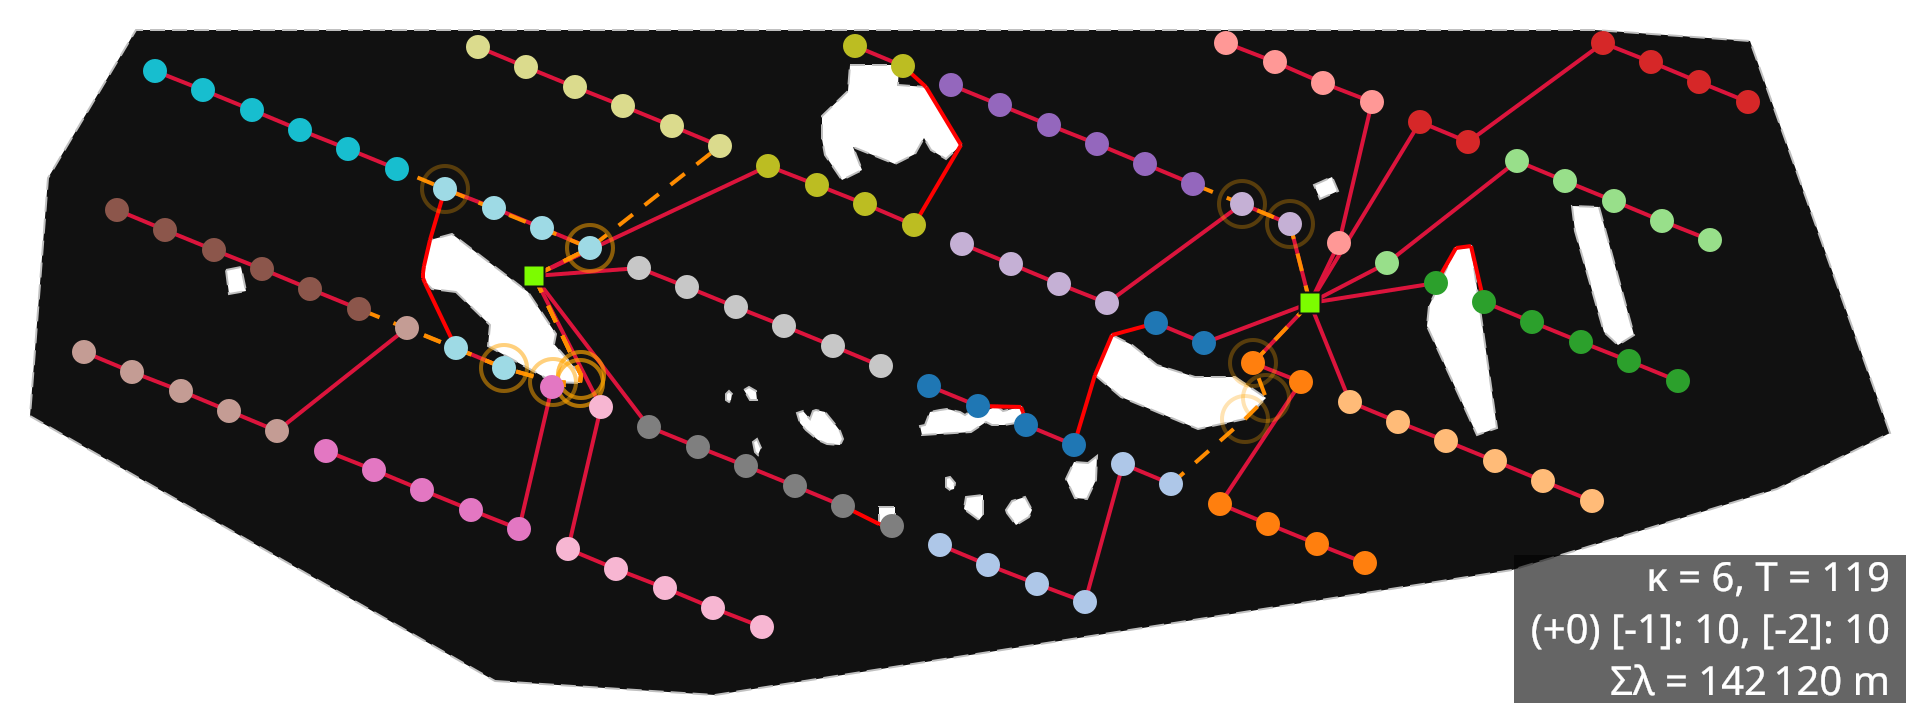

In [10]:
Gʹ = G_from_S(Sʹ, A)
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [11]:
1 - Hʹ.size(weight='length')/λ_branched

0.08072719882818791

In [12]:
solver.set_problem(
    P, A_norm,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology="branched",
        feeder_route="segmented",
        feeder_limit="minimum",
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [13]:
solver.solve(
    mip_gap=0.005,
    time_limit=20,
    verbose=True,
    options=dict(mipfocus=1),
)

Set parameter TimeLimit to value 20
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  20
MIPGap  0.005
MIPFocus  1

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 3851 rows, 2592 columns and 14304 nonzeros (Min)
Model fingerprint: 0xdde0f52f
Model has 1296 linear objective coefficients
Variable types: 0 continuous, 2592 integer (1296 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [5e-02, 1e+00]
  Bounds range     [1e+00, 6e+00]
  RHS range        [1e+00, 1e+02]

Loaded user MIP start with objective 10.8479

Presolve removed 413 rows and 0 columns
Presolve time: 0.02s
Presolved: 3438 rows, 2592 columns, 13240

SolutionInfo(runtime=20.020058155059814, bound=10.395304880083865, objective=10.569582956093555, relgap=0.016488642620399285, termination='maxTimeLimit')

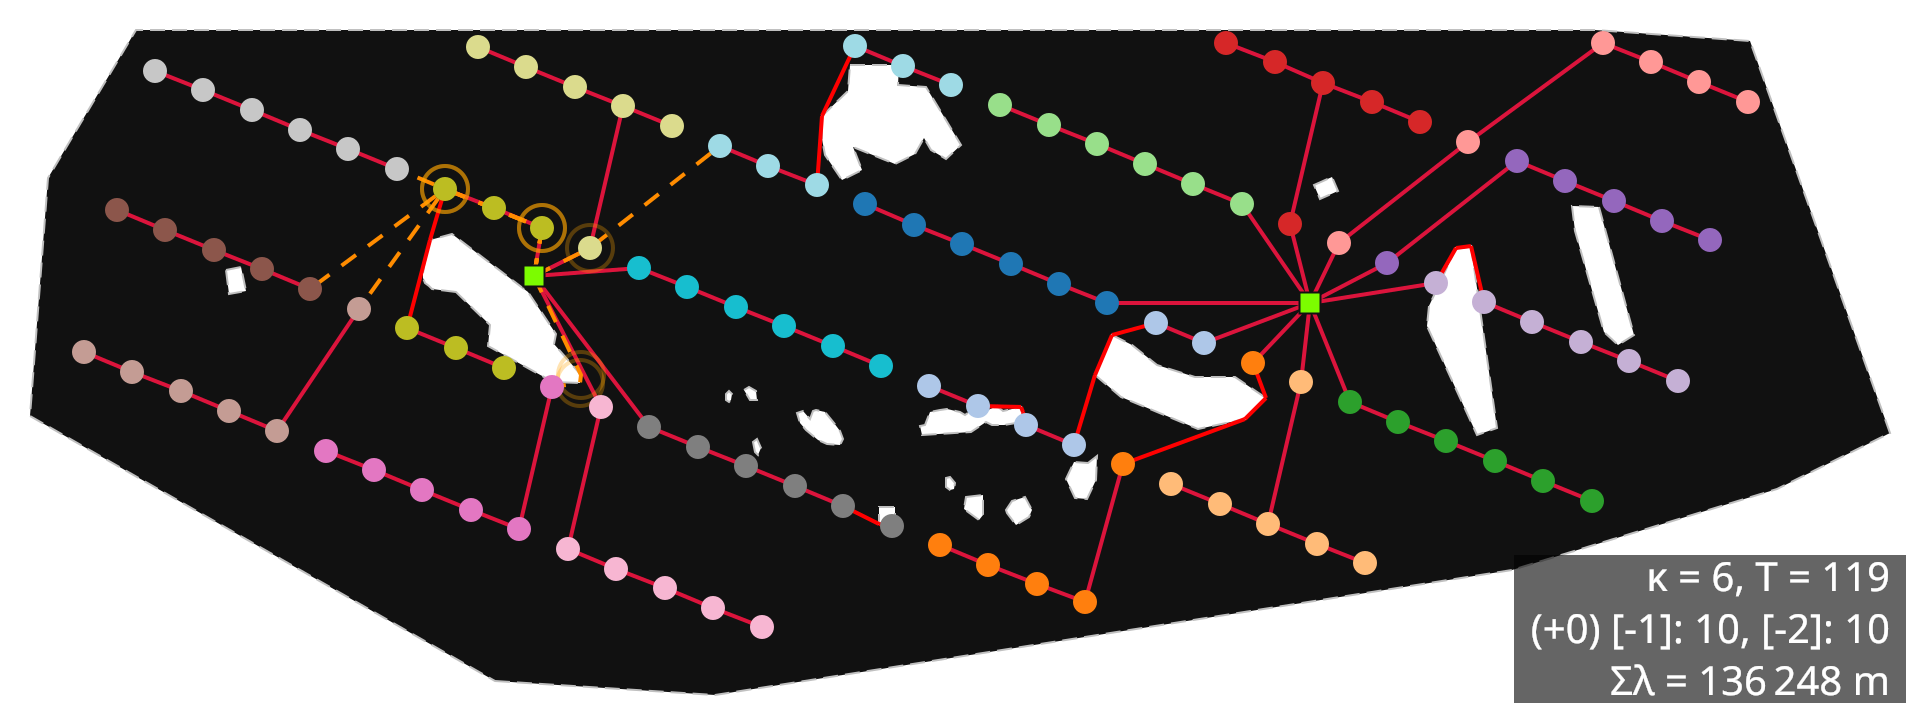

In [14]:
S, G = solver.get_solution(A)
svgplot(G)

In [15]:
1 - G.size(weight='length')/λ_branched

0.11870889630466375

In [16]:
pickle.dump(G, open('yi_2019_κ_6_branched_our.pkl', 'wb'))

### Solve κ = 6 (radial)

In [17]:
Sʹ = hgs_cvrp(A_norm, capacity=6, time_limit=0.5, vehicles=20)
Sʹ.graph['solution_time']

(0.15, 0.17)

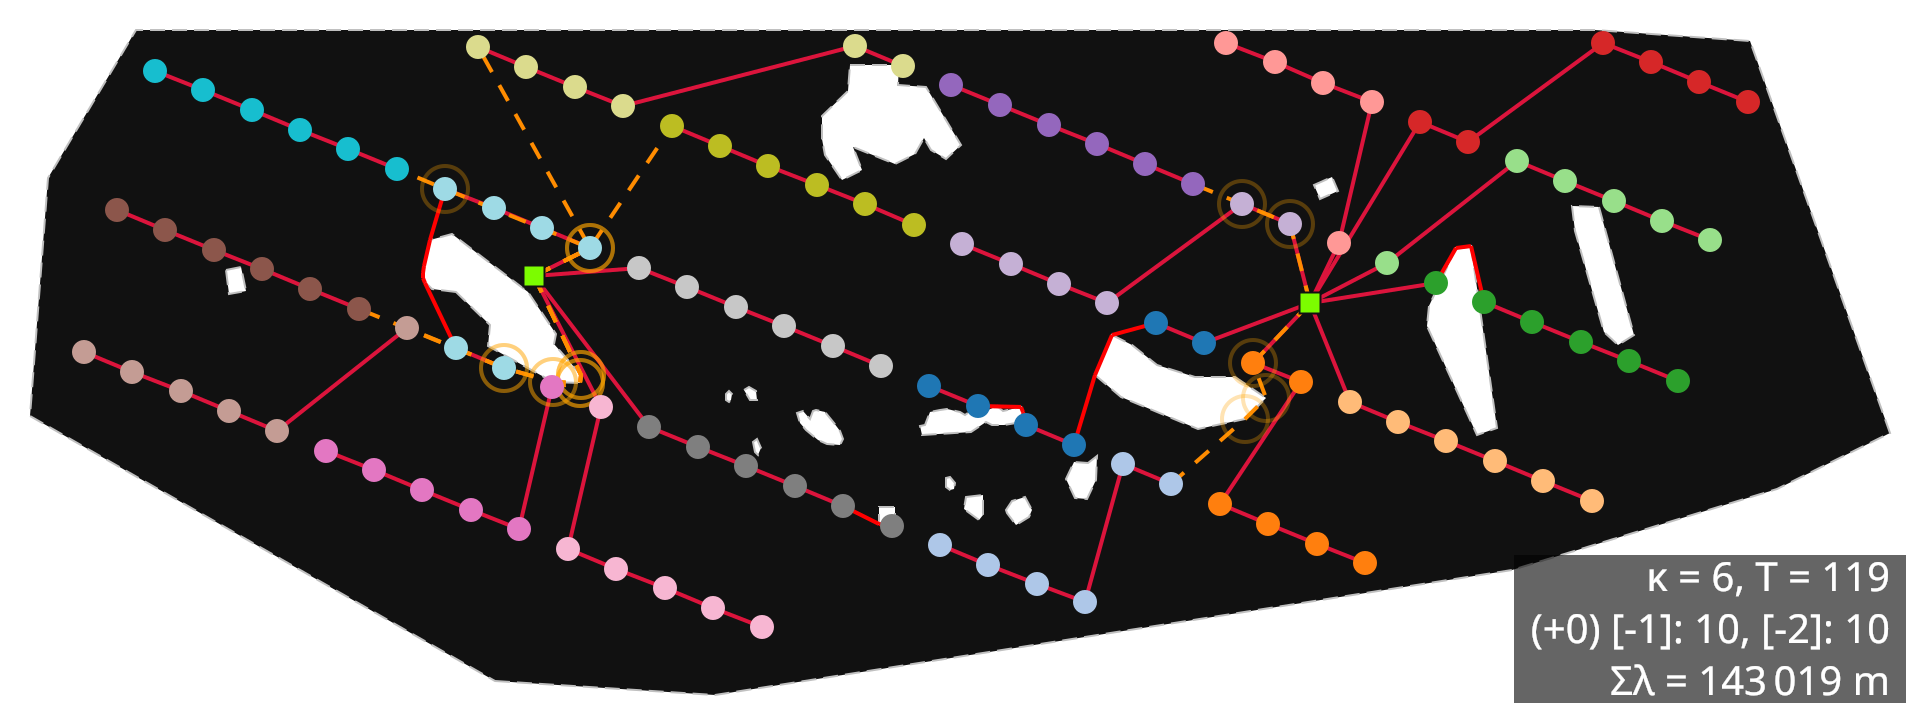

In [18]:
Gʹ = G_from_S(Sʹ, A)
Hʹ = PathFinder(Gʹ, planar=P, A=A).create_detours()
svgplot(Hʹ)

In [19]:
1 - Hʹ.size(weight='length')/λ_radial

0.11879904741864977

In [20]:
solver.set_problem(
    P, A_norm,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology="radial",
        feeder_route="segmented",
        feeder_limit="minimum",
    ),
    warmstart=Sʹ,
)

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 937681
Set parameter MIPFocus to value 1
Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk


In [21]:
solver.solve(
    mip_gap=0.005,
    time_limit=20,
    verbose=True,
    options=dict(mipfocus=1),
)

Set parameter TimeLimit to value 20
Set parameter MIPGap to value 0.005
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux forky/sid")

CPU model: 11th Gen Intel(R) Core(TM) i7-11850H @ 2.50GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  20
MIPGap  0.005
MIPFocus  1

Academic license 937681 - for non-commercial use only - registered to ma___@dtu.dk
Optimize a model with 3970 rows, 2592 columns and 15362 nonzeros (Min)
Model fingerprint: 0x3210d1ca
Model has 1296 linear objective coefficients
Variable types: 0 continuous, 2592 integer (1296 binary)
Coefficient statistics:
  Matrix range     [1e+00, 6e+00]
  Objective range  [5e-02, 1e+00]
  Bounds range     [1e+00, 6e+00]
  RHS range        [1e+00, 1e+02]

Loaded user MIP start with objective 10.8388

Presolve removed 413 rows and 0 columns
Presolve time: 0.02s
Presolved: 3557 rows, 2592 columns, 14298

SolutionInfo(runtime=20.019608974456787, bound=10.445740397215408, objective=10.602780496104984, relgap=0.014811218523977376, termination='maxTimeLimit')

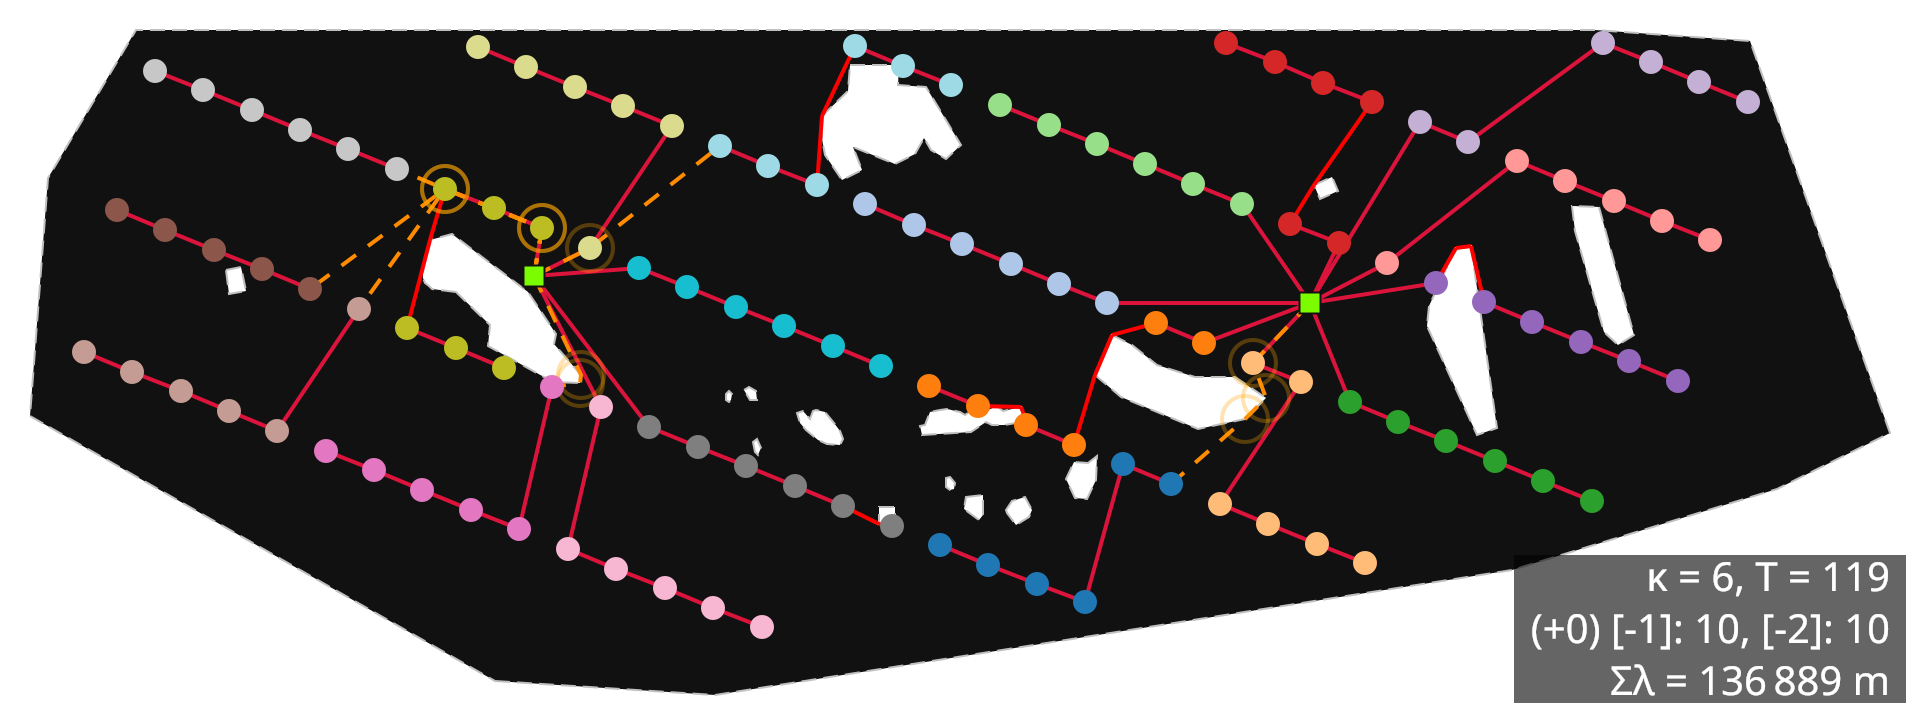

In [22]:
S, G = solver.get_solution(A)
svgplot(G)

In [23]:
1 - G.size(weight='length')/λ_radial

0.15656842404750126

In [24]:
pickle.dump(G, open('yi_2019_κ_6_radial_our.pkl', 'wb'))